# Frozen Feature kNN Model Comparison

Run one or more frozen DINO-style backbones on the same dataset fraction. Smoke runs are not saved; full-dataset runs can cache features and save compact result tables.

In [1]:
import os

os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

print("Project root:", project_root)

Project root: /home/jovyan/xai/xai_for_medical_fm


In [2]:
import gc

import pandas as pd
import torch
import transformers
from torch.utils.data import DataLoader

from src.data import get_small_data
from src.model import extract_feature_bank, get_dino_backbone, model_metadata
from src.results import (
    feature_bank_exists,
    load_feature_bank,
    make_run_dir,
    save_feature_bank,
    save_knn_outputs,
    validate_save_request,
)
from src.train import (
    DEFAULT_KNN_FEWSHOT_SETTINGS,
    filter_knn_fewshot_settings,
    run_knn_fewshot_experiment,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Config

In [3]:
dataset_name = "chestmnist"
data_fraction = 1.00
dataset_seed = 0
save_outputs = True
# Partial saved runs go under outputs/<dataset>/_partial/...
# Full saved runs go under outputs/<dataset>/<run_name>/.

threshold = 0.05
knn_batch_size = 256
seeds = list(range(10))
output_root = project_root / "outputs"

model_configs = [
    {
        "run_name": "dinov2_small_224",
        "model_name": "facebook/dinov2-small",
        "image_size": 224,
        "batch_size": 32,
    },
    {
        "run_name": "dinov2_large_224",
        "model_name": "facebook/dinov2-large",
        "image_size": 224,
        "batch_size": 16,
    },
    {
        "run_name": "dinov3_large_224",
        "model_name": "facebook/dinov3-vitl16-pretrain-lvd1689m",
        "image_size": 224,
        "batch_size": 16,
    },
    {
        "run_name": "stanford_dinov2_xray_224",
        "model_name": "StanfordAIMI/dinov2-base-xray-224",
        "image_size": 224,
        "batch_size": 16,
    },
    {
        "run_name": "rad_dino_518",
        "model_name": "microsoft/rad-dino",
        "image_size": 518,
        "batch_size": 8,
    },
]

validate_save_request(save_outputs, data_fraction)
models_to_run = model_configs
models_to_run

[{'run_name': 'dinov2_small_224',
  'model_name': 'facebook/dinov2-small',
  'image_size': 224,
  'batch_size': 32},
 {'run_name': 'dinov2_large_224',
  'model_name': 'facebook/dinov2-large',
  'image_size': 224,
  'batch_size': 16},
 {'run_name': 'dinov3_large_224',
  'model_name': 'facebook/dinov3-vitl16-pretrain-lvd1689m',
  'image_size': 224,
  'batch_size': 16},
 {'run_name': 'stanford_dinov2_xray_224',
  'model_name': 'StanfordAIMI/dinov2-base-xray-224',
  'image_size': 224,
  'batch_size': 16},
 {'run_name': 'rad_dino_518',
  'model_name': 'microsoft/rad-dino',
  'image_size': 518,
  'batch_size': 8}]

## Run Experiments

In [4]:
all_summaries = []
all_per_class_full = []
all_metadata = []

for model_config in models_to_run:
    run_name = model_config["run_name"]
    model_name = model_config["model_name"]
    image_size = model_config["image_size"]
    batch_size = model_config["batch_size"]
    run_dir = make_run_dir(
        output_root,
        dataset_name,
        run_name,
        data_fraction=data_fraction,
        dataset_seed=dataset_seed,
    )

    print("\n" + "=" * 80)
    print(run_name)
    print(model_name)

    train_loader, val_loader, class_names = get_small_data(
        batch_size=batch_size,
        image_size=image_size,
        data_fraction=data_fraction,
        seed=dataset_seed,
    )
    train_feature_loader = DataLoader(
        train_loader.dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )
    val_feature_loader = DataLoader(
        val_loader.dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    context = {
        "dataset_name": dataset_name,
        "run_name": run_name,
        "model_name": model_name,
        "image_size": image_size,
    }

    if save_outputs and feature_bank_exists(run_dir):
        print("loading cached features")
        feature_bank, feature_metadata = load_feature_bank(run_dir)
    else:
        model = get_dino_backbone(model_name).to(device)
        backbone_metadata = model_metadata(model)
        print("total params:", f"{backbone_metadata['total_params']:,}")
        print("trainable params:", f"{backbone_metadata['trainable_params']:,}")

        feature_bank, feature_metadata = extract_feature_bank(
            model,
            train_feature_loader,
            val_feature_loader,
            device,
            class_names=class_names,
        )
        feature_metadata = {
            **context,
            **backbone_metadata,
            **feature_metadata,
        }

        del model
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()

        if save_outputs:
            save_feature_bank(run_dir, feature_bank, metadata=feature_metadata)

    settings = filter_knn_fewshot_settings(
        DEFAULT_KNN_FEWSHOT_SETTINGS,
        feature_bank["train_features"].shape[0],
    )
    knn_outputs = run_knn_fewshot_experiment(
        train_features=feature_bank["train_features"],
        train_labels=feature_bank["train_labels"],
        val_features=feature_bank["val_features"],
        val_labels=feature_bank["val_labels"],
        class_names=feature_bank["class_names"],
        settings=settings,
        seeds=seeds,
        threshold=threshold,
        batch_size=knn_batch_size,
        device=device,
        context=context,
    )

    metadata = {
        **context,
        "data_fraction": data_fraction,
        "dataset_seed": dataset_seed,
        "batch_size": batch_size,
        "knn_batch_size": knn_batch_size,
        "threshold": threshold,
        "n_train": int(feature_bank["train_features"].shape[0]),
        "n_val": int(feature_bank["val_features"].shape[0]),
        "device": device,
        "torch_version": torch.__version__,
        "transformers_version": transformers.__version__,
        **feature_metadata,
        **knn_outputs["metadata"],
    }

    if save_outputs:
        save_knn_outputs(
            run_dir,
            runs_df=knn_outputs["runs"],
            summary_df=knn_outputs["summary"],
            per_class_full_df=knn_outputs["per_class_full"],
            metadata=metadata,
        )

    all_summaries.append(knn_outputs["summary"])
    all_per_class_full.append(knn_outputs["per_class_full"])
    all_metadata.append(metadata)

combined_summary_df = pd.concat(all_summaries, ignore_index=True)
combined_per_class_full_df = pd.concat(all_per_class_full, ignore_index=True)
combined_summary_df


dinov2_small_224
facebook/dinov2-small
Using downloaded and verified file: /home/jovyan/.medmnist/chestmnist.npz
Using downloaded and verified file: /home/jovyan/.medmnist/chestmnist.npz
total params: 22,056,576
trainable params: 0


Extracting features:   0%|          | 0/2453 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/351 [00:00<?, ?it/s]


dinov2_large_224
facebook/dinov2-large
Using downloaded and verified file: /home/jovyan/.medmnist/chestmnist.npz
Using downloaded and verified file: /home/jovyan/.medmnist/chestmnist.npz
total params: 304,368,640
trainable params: 0


Extracting features:   0%|          | 0/4905 [00:00<?, ?it/s]

...


rad_dino_518
microsoft/rad-dino
Using downloaded and verified file: /home/jovyan/.medmnist/chestmnist.npz
Using downloaded and verified file: /home/jovyan/.medmnist/chestmnist.npz
total params: 86,580,480
trainable params: 0


Extracting features:   0%|          | 0/9809 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Extracting features:   0%|          | 0/1403 [00:00<?, ?it/s]

,dataset_name,run_name,model_name,image_size,setting,n_train,k,threshold,positive_neighbors_needed,runs,classes_with_positive_train_examples_mean,mean_auc_mean,mean_auc_std,f1_macro_mean,f1_macro_std,f1_micro_mean,f1_micro_std,mean_accuracy_mean,exact_match_accuracy_mean
0,chestmnist,dinov2_small_224,facebook/dinov2-small,224,1-img,1,1,0.05,1,10,0.6,0.500000,0.000000,0.008635,0.013678,0.062463,0.093240,0.916346,0.343952
1,chestmnist,dinov2_small_224,facebook/dinov2-small,224,2-img,2,1,0.05,1,10,1.5,0.501654,0.005268,0.017983,0.019781,0.072592,0.082591,0.914179,0.330858
2,chestmnist,dinov2_small_224,facebook/dinov2-small,224,5-img,5,3,0.05,1,10,3.1,0.502438,0.004195,0.033722,0.019001,0.132376,0.067209,0.839746,0.108254
3,chestmnist,dinov2_small_224,facebook/dinov2-small,224,10-img,10,5,0.05,1,10,4.9,0.507614,0.004875,0.046539,0.017386,0.132852,0.042684,0.797386,0.061102
4,chestmnist,dinov2_small_224,facebook/dinov2-small,224,20-img,20,5,0.05,1,10,7.6,0.514365,0.012242,0.064836,0.015608,0.144439,0.028446,0.801222,0.086541
5,chestmnist,dinov2_small_224,facebook/dinov2-small,224,25-img,25,5,0.05,1,10,8.2,0.515134,0.011404,0.068226,0.012800,0.148670,0.023799,0.811314,0.079544
6,chestmnist,dinov2_small_224,facebook/dinov2-small,224,50-img,50,10,0.05,1,10,11.1,0.522638,0.012348,0.087667,0.008507,0.145855,0.008042,0.668001,0.018816
7,chestmnist,dinov2_small_224,facebook/dinov2-small,224,100-img,100,20,0.05,1,10,12.7,0.536236,0.010263,0.096074,0.003448,0.140335,0.008144,0.531838,0.000463
8,chestmnist,dinov2_small_224,facebook/dinov2-small,224,500-img,500,50,0.05,3,10,13.6,0.578056,0.011634,0.103447,0.003776,0.182510,0.004684,0.689186,0.003093
9,chestmnist,dinov2_small_224,facebook/dinov2-small,224,1000-img,1000,50,0.05,3,10,13.8,0.590811,0.006143,0.108553,0.003972,0.183845,0.004839,0.687942,0.003913


## Compare Full Reference Rows

In [5]:
full_rows_df = combined_summary_df[combined_summary_df["setting"] == "full"].copy()
full_rows_df[
    [
        "run_name",
        "model_name",
        "image_size",
        "n_train",
        "k",
        "mean_auc_mean",
        "f1_macro_mean",
        "f1_micro_mean",
        "mean_accuracy_mean",
        "exact_match_accuracy_mean",
    ]
]

,run_name,model_name,image_size,n_train,k,mean_auc_mean,f1_macro_mean,f1_micro_mean,mean_accuracy_mean,exact_match_accuracy_mean
11,dinov2_small_224,facebook/dinov2-small,224,78468,2000,0.689121,0.119987,0.204271,0.706798,0.003298
23,dinov2_large_224,facebook/dinov2-large,224,78468,2000,0.668293,0.103296,0.196639,0.695669,0.001604
35,dinov3_large_224,facebook/dinov3-vitl16-pretrain-lvd1689m,224,78468,2000,0.686784,0.118225,0.207019,0.717883,0.003922
47,stanford_dinov2_xray_224,StanfordAIMI/dinov2-base-xray-224,224,78468,2000,0.762553,0.158483,0.234865,0.746043,0.014885
59,rad_dino_518,microsoft/rad-dino,518,78468,2000,0.759266,0.156550,0.232196,0.736964,0.018273


In [6]:
metadata_df = pd.DataFrame(all_metadata)
metadata_df[
    [
        "run_name",
        "model_name",
        "image_size",
        "total_params",
        "trainable_params",
        "feature_dim",
        "feature_extraction_seconds",
        "knn_eval_seconds",
        "peak_gpu_memory_mb",
    ]
]

,run_name,model_name,image_size,total_params,trainable_params,feature_dim,feature_extraction_seconds,knn_eval_seconds,peak_gpu_memory_mb
0,dinov2_small_224,facebook/dinov2-small,224,22056576,0,384,457.010648,15.536378,291.389160
1,dinov2_large_224,facebook/dinov2-large,224,304368640,0,1024,4476.860589,16.246857,1419.613281
2,dinov3_large_224,facebook/dinov3-vitl16-pretrain-lvd1689m,224,303129600,0,1024,3654.316963,18.401664,1325.445801
3,stanford_dinov2_xray_224,StanfordAIMI/dinov2-base-xray-224,224,85725696,0,768,1295.680370,15.671713,526.082031
4,rad_dino_518,microsoft/rad-dino,518,86580480,0,768,8870.750292,16.052986,845.885254


## Visualize Model Comparison

In [7]:
import matplotlib.pyplot as plt
import numpy as np

display_names = {
    "dinov2_small_224": "DINOv2-S 224",
    "dinov2_large_224": "DINOv2-L 224",
    "dinov3_large_224": "DINOv3-L 224",
    "stanford_dinov2_xray_224": "Stanford X-ray DINOv2-B 224",
    "rad_dino_518": "RAD-DINO 518",
}

model_groups = {
    "dinov2_small_224": "Generic DINOv2",
    "dinov2_large_224": "Generic DINOv2",
    "dinov3_large_224": "Generic DINOv3",
    "stanford_dinov2_xray_224": "Medical/X-ray",
    "rad_dino_518": "Medical/X-ray",
}

group_colors = {
    "Generic DINOv2": "tab:blue",
    "Generic DINOv3": "tab:purple",
    "Medical/X-ray": "tab:green",
}

plot_summary_df = combined_summary_df.copy()
plot_summary_df["display_name"] = plot_summary_df["run_name"].map(display_names).fillna(plot_summary_df["run_name"].str.replace("_", " "))
plot_summary_df["model_group"] = plot_summary_df["run_name"].map(model_groups).fillna("Other")

plot_metadata_df = metadata_df.copy()
plot_metadata_df["display_name"] = plot_metadata_df["run_name"].map(display_names).fillna(plot_metadata_df["run_name"].str.replace("_", " "))
plot_metadata_df["model_group"] = plot_metadata_df["run_name"].map(model_groups).fillna("Other")

plot_per_class_df = combined_per_class_full_df.copy()
plot_per_class_df["display_name"] = plot_per_class_df["run_name"].map(display_names).fillna(plot_per_class_df["run_name"].str.replace("_", " "))
plot_per_class_df["model_group"] = plot_per_class_df["run_name"].map(model_groups).fillna("Other")

### Few-Shot Curves by Model

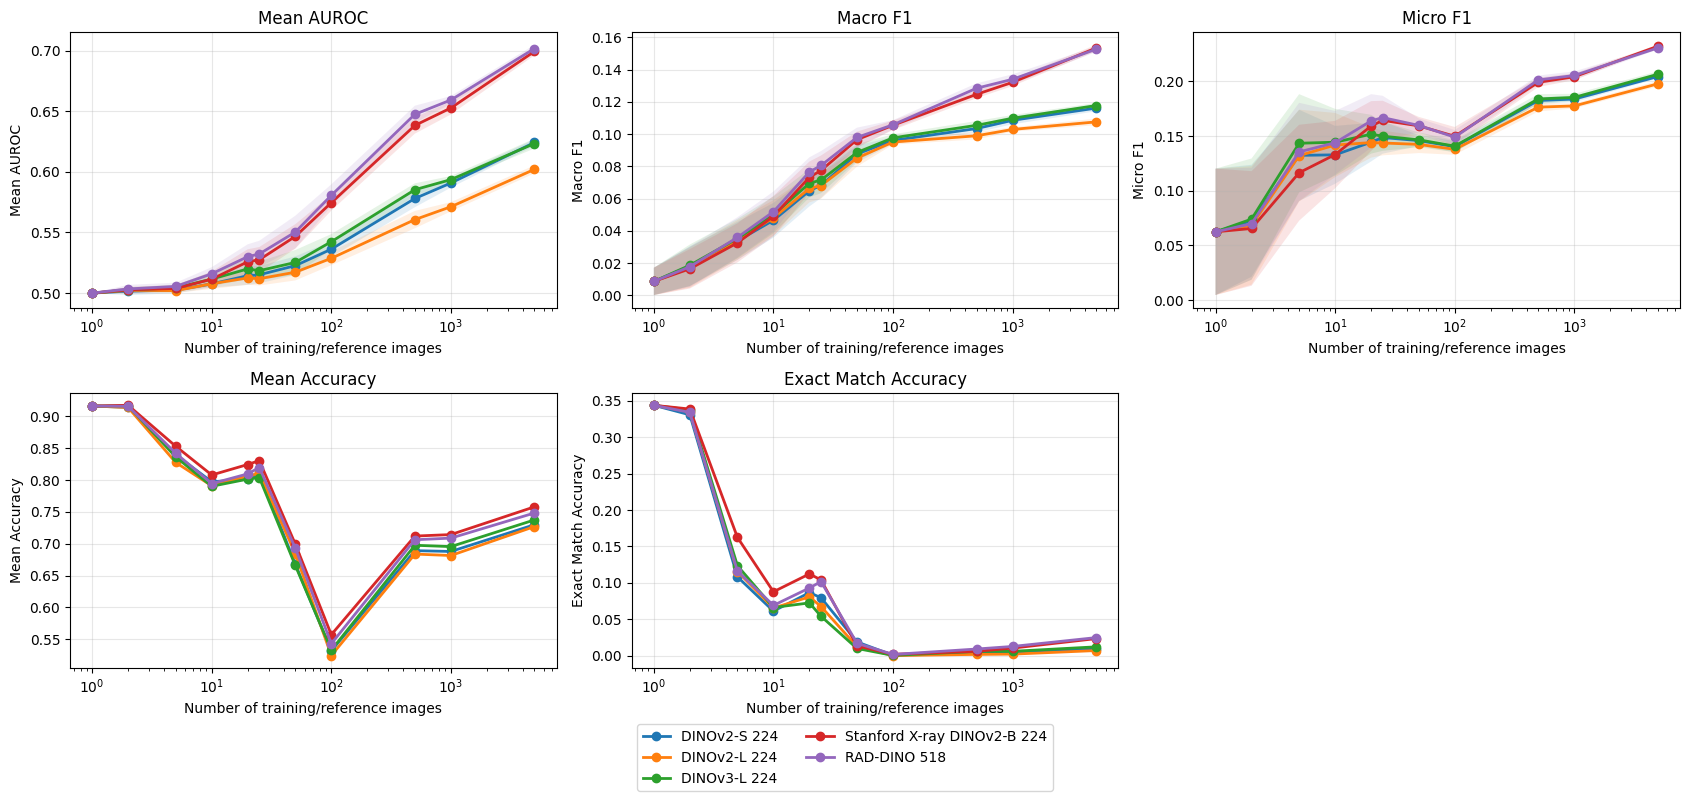

In [8]:
metrics_to_plot = [
    ("mean_auc_mean", "mean_auc_std", "Mean AUROC"),
    ("f1_macro_mean", "f1_macro_std", "Macro F1"),
    ("f1_micro_mean", "f1_micro_std", "Micro F1"),
    ("mean_accuracy_mean", None, "Mean Accuracy"),
    ("exact_match_accuracy_mean", None, "Exact Match Accuracy"),
]

fewshot_plot_df = plot_summary_df[plot_summary_df["setting"] != "full"].copy()

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
axes = axes.ravel()

for ax, (mean_col, std_col, title) in zip(axes, metrics_to_plot):
    for display_name, group_df in fewshot_plot_df.groupby("display_name", sort=False):
        group_df = group_df.sort_values("n_train")
        x = group_df["n_train"].astype(float).to_numpy()
        y = group_df[mean_col].astype(float).to_numpy()

        ax.plot(x, y, marker="o", linewidth=2, label=display_name)

        if std_col is not None and group_df[std_col].notna().any():
            std = group_df[std_col].astype(float).fillna(0).to_numpy()
            runs = group_df["runs"].astype(float).to_numpy()
            ci95 = 1.96 * std / np.sqrt(runs)
            ax.fill_between(x, y - ci95, y + ci95, alpha=0.12)

    ax.set_xscale("log")
    ax.set_xlabel("Number of training/reference images")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[-1].axis("off")
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=2)
fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

### Full-Reference Metrics

/tmp/ipykernel_6290/2210575997.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_values, labels=model_order, showmeans=True)
/tmp/ipykernel_6290/2210575997.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_values, labels=model_order, showmeans=True)


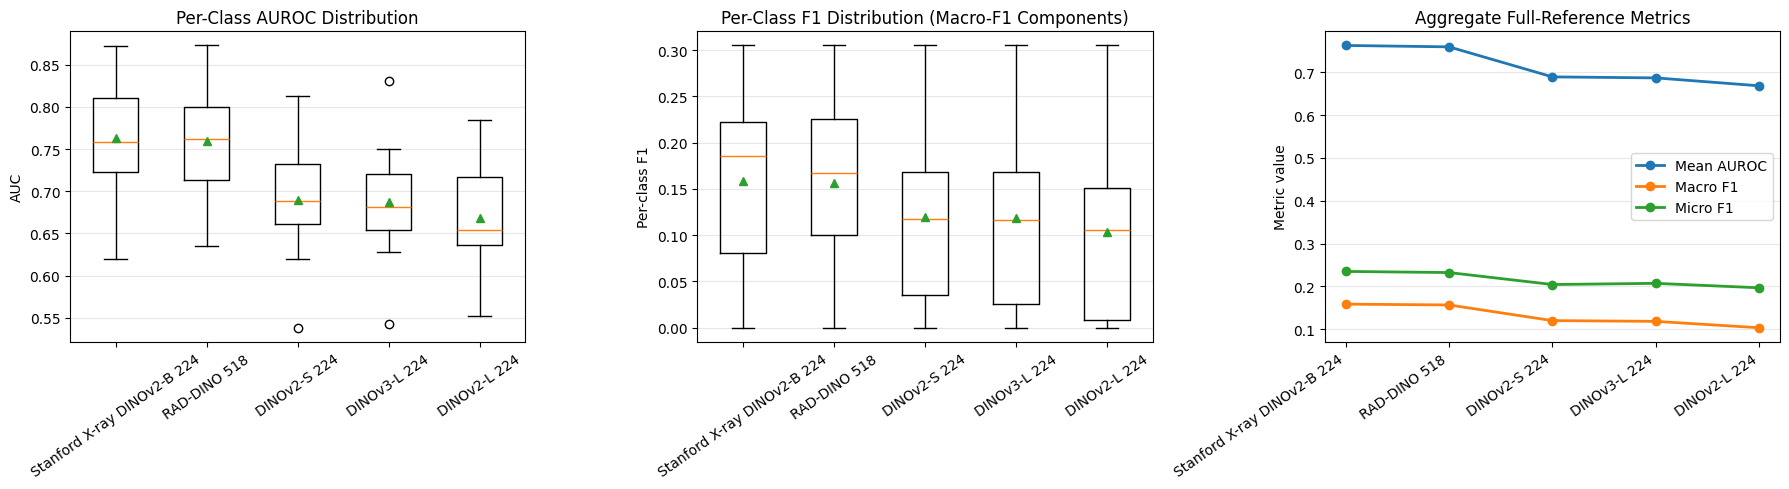

,display_name,model_name,image_size,n_train,k,threshold,mean_auc_mean,f1_macro_mean,f1_micro_mean,mean_accuracy_mean,exact_match_accuracy_mean
47,Stanford X-ray DINOv2-B 224,StanfordAIMI/dinov2-base-xray-224,224,78468,2000,0.05,0.762553,0.158483,0.234865,0.746043,0.014885
59,RAD-DINO 518,microsoft/rad-dino,518,78468,2000,0.05,0.759266,0.156550,0.232196,0.736964,0.018273
11,DINOv2-S 224,facebook/dinov2-small,224,78468,2000,0.05,0.689121,0.119987,0.204271,0.706798,0.003298
35,DINOv3-L 224,facebook/dinov3-vitl16-pretrain-lvd1689m,224,78468,2000,0.05,0.686784,0.118225,0.207019,0.717883,0.003922
23,DINOv2-L 224,facebook/dinov2-large,224,78468,2000,0.05,0.668293,0.103296,0.196639,0.695669,0.001604


In [9]:
full_plot_df = plot_summary_df[plot_summary_df["setting"] == "full"].copy()
full_plot_df = full_plot_df.sort_values("mean_auc_mean", ascending=False)
model_order = full_plot_df["display_name"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

box_specs = [
    ("auc", "Per-Class AUROC Distribution"),
    ("f1", "Per-Class F1 Distribution (Macro-F1 Components)"),
]

for ax, (value_col, title) in zip(axes[:2], box_specs):
    box_values = [
        plot_per_class_df.loc[plot_per_class_df["display_name"] == name, value_col].dropna().to_numpy()
        for name in model_order
    ]
    ax.boxplot(box_values, labels=model_order, showmeans=True)
    ax.set_title(title)
    ax.set_ylabel(value_col.upper() if value_col == "auc" else "Per-class F1")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, axis="y", alpha=0.3)

aggregate_metrics = [
    ("mean_auc_mean", "Mean AUROC"),
    ("f1_macro_mean", "Macro F1"),
    ("f1_micro_mean", "Micro F1"),
]
x = np.arange(len(model_order))
for metric_col, label in aggregate_metrics:
    y = full_plot_df.set_index("display_name").loc[model_order, metric_col].to_numpy()
    axes[2].plot(x, y, marker="o", linewidth=2, label=label)

axes[2].set_xticks(x)
axes[2].set_xticklabels(model_order, rotation=35, ha="right")
axes[2].set_title("Aggregate Full-Reference Metrics")
axes[2].set_ylabel("Metric value")
axes[2].grid(True, axis="y", alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

full_plot_df[
    [
        "display_name",
        "model_name",
        "image_size",
        "n_train",
        "k",
        "threshold",
        "mean_auc_mean",
        "f1_macro_mean",
        "f1_micro_mean",
        "mean_accuracy_mean",
        "exact_match_accuracy_mean",
    ]
]

### Efficiency vs Performance

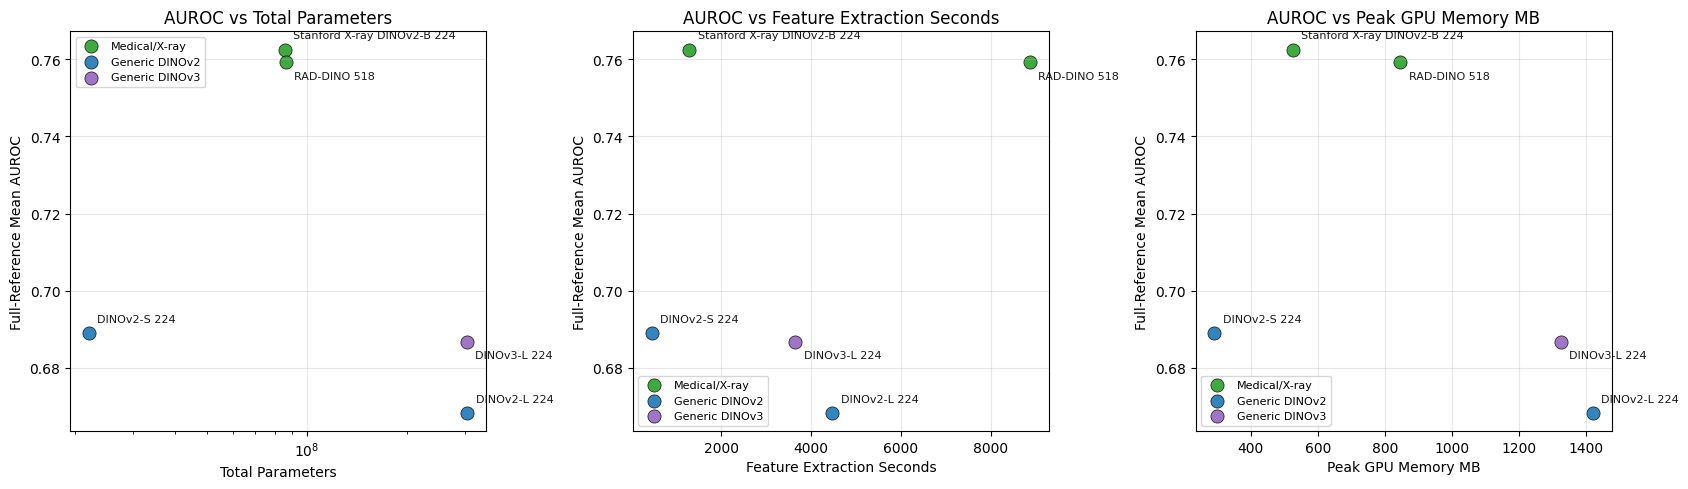

,run_name,model_group,mean_auc_mean,f1_macro_mean,f1_micro_mean,total_params,trainable_params,feature_dim,feature_extraction_seconds,knn_eval_seconds,peak_gpu_memory_mb
0,stanford_dinov2_xray_224,Medical/X-ray,0.762553,0.158483,0.234865,85725696,0,768,1295.680370,15.671713,526.082031
1,rad_dino_518,Medical/X-ray,0.759266,0.156550,0.232196,86580480,0,768,8870.750292,16.052986,845.885254
2,dinov2_small_224,Generic DINOv2,0.689121,0.119987,0.204271,22056576,0,384,457.010648,15.536378,291.389160
3,dinov3_large_224,Generic DINOv3,0.686784,0.118225,0.207019,303129600,0,1024,3654.316963,18.401664,1325.445801
4,dinov2_large_224,Generic DINOv2,0.668293,0.103296,0.196639,304368640,0,1024,4476.860589,16.246857,1419.613281


In [10]:
efficiency_df = full_plot_df.merge(
    plot_metadata_df,
    on=["dataset_name", "run_name", "model_name", "image_size", "display_name", "model_group"],
    how="left",
    suffixes=("", "_metadata"),
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

scatter_specs = [
    ("total_params", "Total Parameters", True),
    ("feature_extraction_seconds", "Feature Extraction Seconds", False),
    ("peak_gpu_memory_mb", "Peak GPU Memory MB", False),
]

for ax, (x_col, x_label, log_x) in zip(axes, scatter_specs):
    plot_df = efficiency_df.dropna(subset=[x_col, "mean_auc_mean"])
    for model_group, group_df in plot_df.groupby("model_group", sort=False):
        ax.scatter(
            group_df[x_col],
            group_df["mean_auc_mean"],
            s=90,
            color=group_colors.get(model_group, "tab:gray"),
            label=model_group,
            alpha=0.9,
            edgecolor="black",
            linewidth=0.5,
        )

    for idx, (_, row) in enumerate(plot_df.iterrows()):
        offset_y = 8 if idx % 2 == 0 else -12
        ax.annotate(
            row["display_name"],
            (row[x_col], row["mean_auc_mean"]),
            textcoords="offset points",
            xytext=(6, offset_y),
            fontsize=8,
            alpha=0.9,
        )

    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Full-Reference Mean AUROC")
    ax.set_title(f"AUROC vs {x_label}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()

efficiency_df[
    [
        "run_name",
        "model_group",
        "mean_auc_mean",
        "f1_macro_mean",
        "f1_micro_mean",
        "total_params",
        "trainable_params",
        "feature_dim",
        "feature_extraction_seconds",
        "knn_eval_seconds",
        "peak_gpu_memory_mb",
    ]
]

### Per-Class Full-Reference Diagnostics

In [11]:
full_per_class_plot_df = plot_per_class_df.copy()

per_class_table_df = full_per_class_plot_df[
    [
        "display_name",
        "class_name",
        "true_positive_rate",
        "predicted_positive_rate",
        "accuracy",
        "f1",
        "auc",
    ]
].sort_values(["display_name", "class_name"])

per_class_table_df

,display_name,class_name,true_positive_rate,predicted_positive_rate,accuracy,f1,auc
14,DINOv2-L 224,atelectasis,0.099742,0.898565,0.197968,0.196607,0.666699
15,DINOv2-L 224,cardiomegaly,0.021392,0.000980,0.978340,0.031873,0.689955
22,DINOv2-L 224,consolidation,0.039843,0.236296,0.762189,0.138799,0.722791
23,DINOv2-L 224,edema,0.017827,0.068990,0.922453,0.106776,0.784345
16,DINOv2-L 224,effusion,0.115162,0.853819,0.256886,0.233097,0.722480
...,...,...,...,...,...,...,...
46,Stanford X-ray DINOv2-B 224,mass,0.055709,0.252251,0.761922,0.226918,0.761285
47,Stanford X-ray DINOv2-B 224,nodule,0.054639,0.551743,0.471165,0.127885,0.619698
54,Stanford X-ray DINOv2-B 224,pleural,0.033158,0.070595,0.915322,0.183849,0.754457
48,Stanford X-ray DINOv2-B 224,pneumonia,0.011855,0.000000,0.988145,0.000000,0.698482


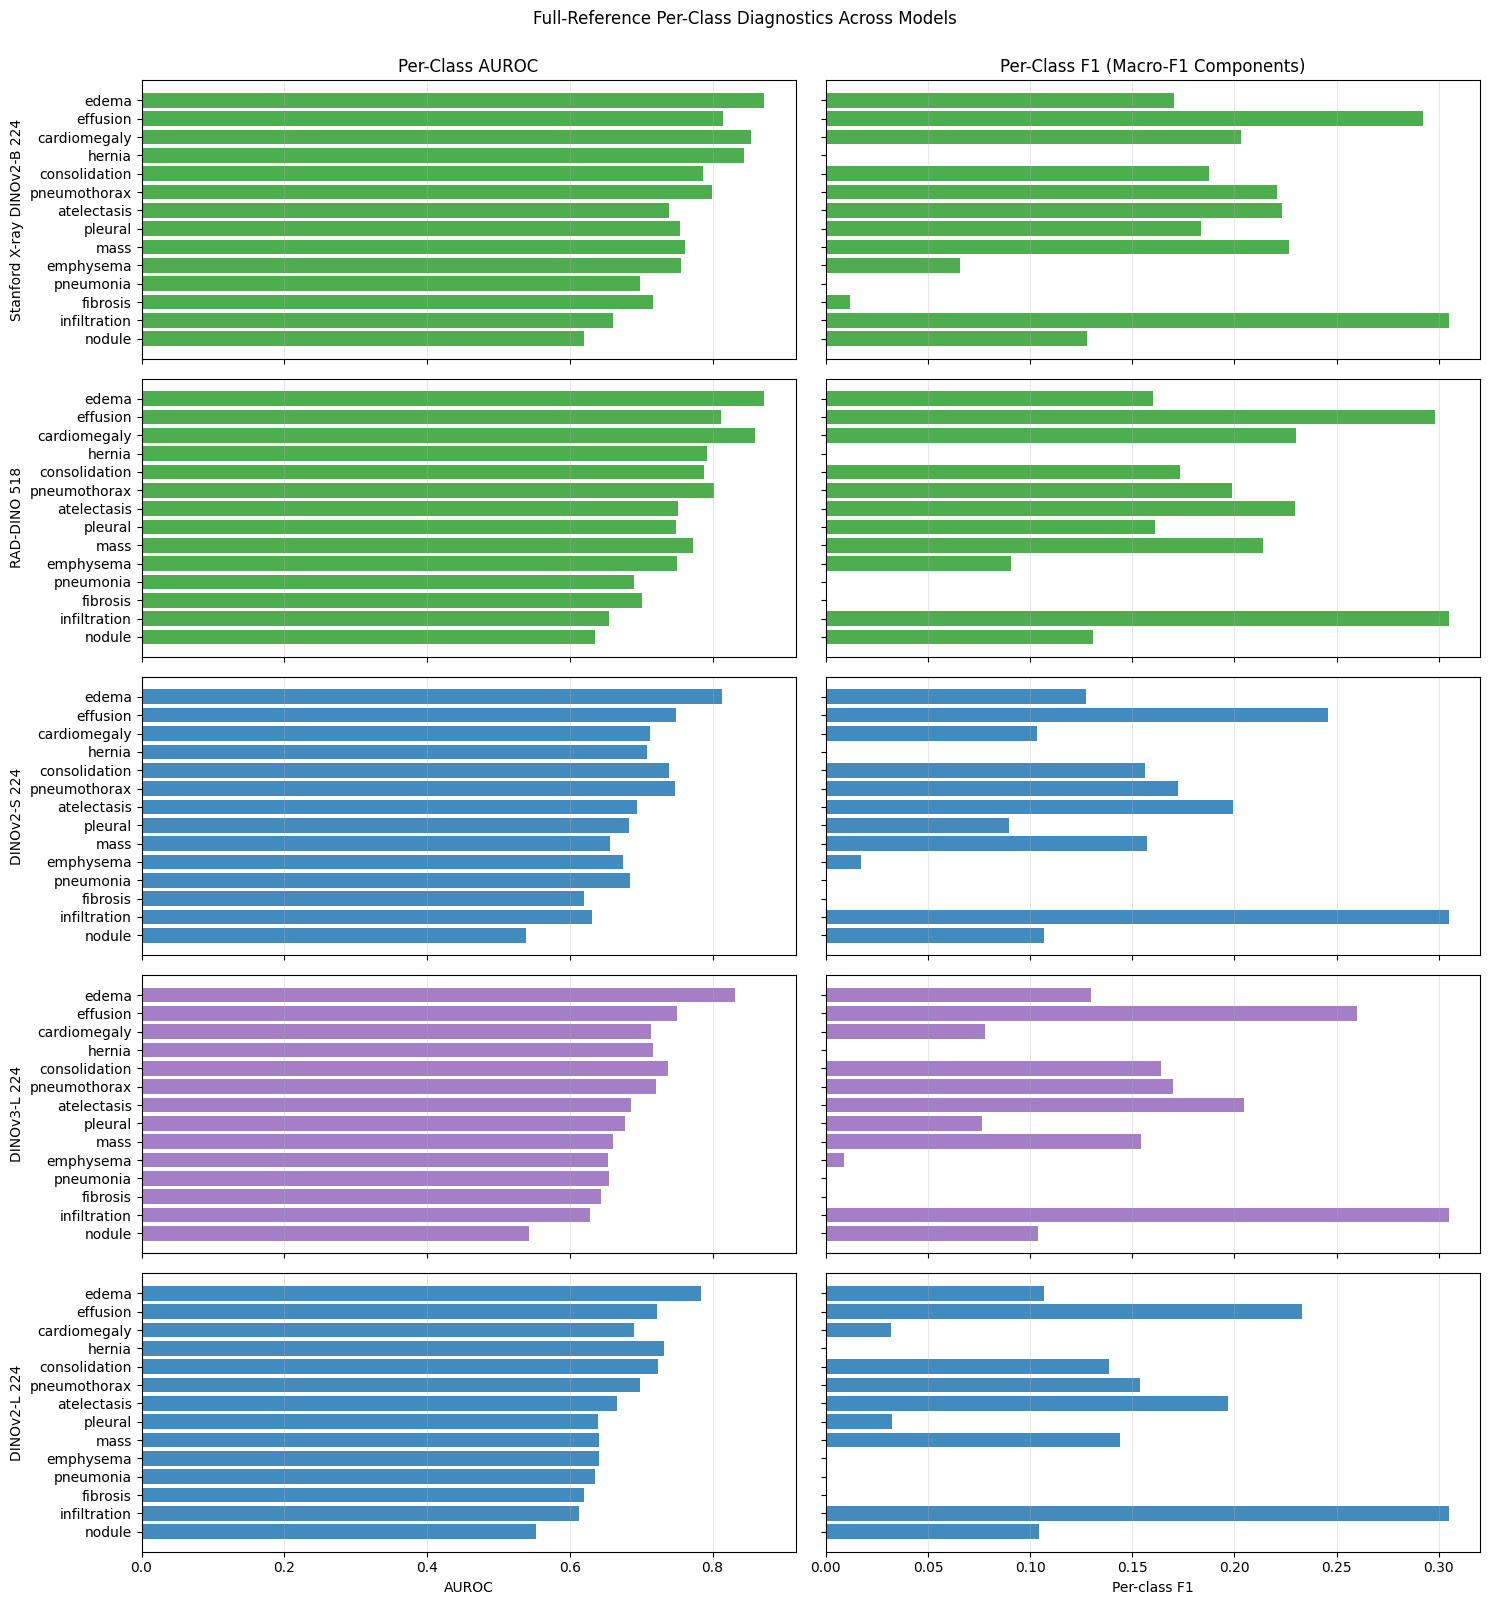

In [12]:
if not full_per_class_plot_df.empty:
    class_order = (
        full_per_class_plot_df.groupby("class_name")["auc"]
        .mean()
        .sort_values(ascending=True)
        .index
        .tolist()
    )
    model_order = [name for name in model_order if name in full_per_class_plot_df["display_name"].unique()]

    fig, axes = plt.subplots(
        len(model_order),
        2,
        figsize=(15, 3.2 * len(model_order)),
        sharex="col",
        sharey=True,
    )
    axes = np.atleast_2d(axes)

    for row_idx, display_name in enumerate(model_order):
        model_df = full_per_class_plot_df[full_per_class_plot_df["display_name"] == display_name]
        model_df = model_df.set_index("class_name").loc[class_order].reset_index()

        color = group_colors.get(model_df["model_group"].iloc[0], "tab:gray")
        axes[row_idx, 0].barh(model_df["class_name"], model_df["auc"], color=color, alpha=0.85)
        axes[row_idx, 1].barh(model_df["class_name"], model_df["f1"], color=color, alpha=0.85)

        axes[row_idx, 0].set_ylabel(display_name)
        axes[row_idx, 0].grid(True, axis="x", alpha=0.3)
        axes[row_idx, 1].grid(True, axis="x", alpha=0.3)

    axes[0, 0].set_title("Per-Class AUROC")
    axes[0, 1].set_title("Per-Class F1 (Macro-F1 Components)")
    axes[-1, 0].set_xlabel("AUROC")
    axes[-1, 1].set_xlabel("Per-class F1")
    fig.suptitle("Full-Reference Per-Class Diagnostics Across Models", y=1.0)
    plt.tight_layout()
    plt.show()